In [18]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor
import xgboost as xgb

In [19]:
# Загрузка данных
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [20]:
# Предварительная обработка
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

In [21]:
# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабируем данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Обучение моделей
# Стекинг
estimators = [
    ('lr', LinearRegression()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)),
    ('xgb', xgb.XGBRegressor(random_state=42))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

stacking_model.fit(X_train_scaled, y_train)
y_pred_stack = stacking_model.predict(X_test_scaled)

# Оценка качества модели стэкинга
mse_stack = mean_squared_error(y_test, y_pred_stack)
rmse_stack = np.sqrt(mse_stack)  # Вычисляем RMSE

print("Стэкинг - RMSE:", rmse_stack)
print("Стэкинг - R2:", r2_score(y_test, y_pred_stack))

Стэкинг - RMSE: 0.46573719925548845
Стэкинг - R2: 0.8344706558241617


In [23]:
# Обучение модели XGBoost
xgboost_model = xgb.XGBRegressor(random_state=42)
xgboost_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgboost_model.predict(X_test_scaled)

In [24]:
# Оценка качества модели XGBoost
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)  # Вычисляем RMSE

In [25]:
print("XGBoost - RMSE:", rmse_xgb)
print("XGBoost - R2:", r2_score(y_test, y_pred_xgb))

XGBoost - RMSE: 0.4717943691423984
XGBoost - R2: 0.8301370561019205


In [26]:
# Визуализация результатов
results = pd.DataFrame({
    'Model': ['Stacking', 'XGBoost'],
    'RMSE': [
        rmse_stack,
        rmse_xgb
    ],
    'R2': [
        r2_score(y_test, y_pred_stack),
        r2_score(y_test, y_pred_xgb)
    ]
})

In [27]:
# Сортировка по RMSE для визуализации
results_sorted = results.sort_values(by="RMSE", ascending=True)

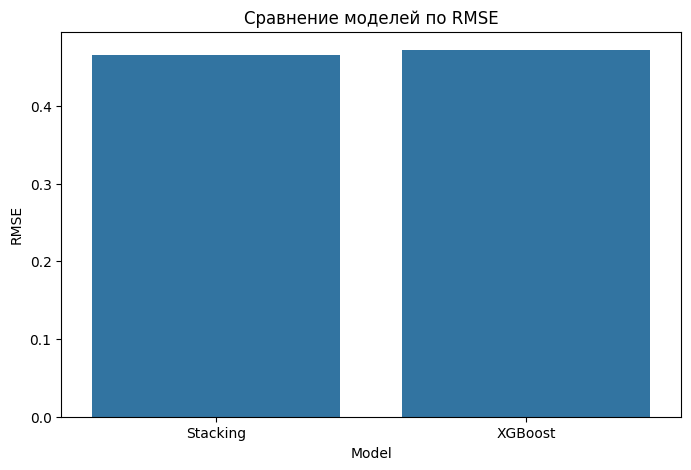

In [28]:
# Визуализация по RMSE
plt.figure(figsize=(8, 5))
sns.barplot(data=results_sorted, x='Model', y='RMSE')
plt.title('Сравнение моделей по RMSE')
plt.show()


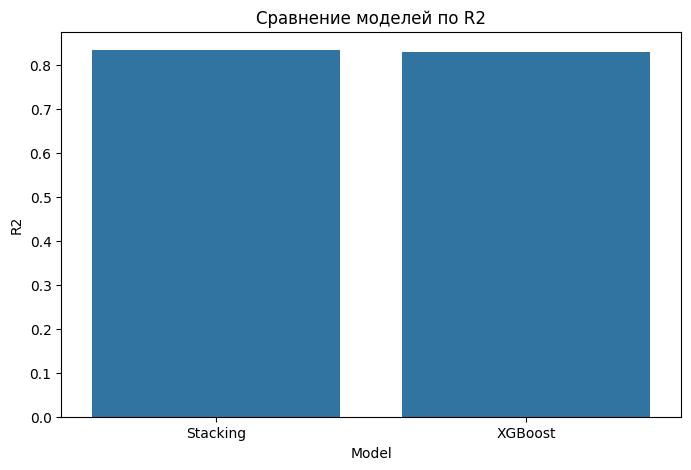

In [29]:
# Визуализация по R2
plt.figure(figsize=(8, 5))
sns.barplot(data=results_sorted, x='Model', y='R2')
plt.title('Сравнение моделей по R2')
plt.show()